# pandasの概要

In [1]:
import pandas as pd

## Series

In [2]:
ser = pd.Series([10, 20, 30, 40])
ser

0    10
1    20
2    30
3    40
dtype: int64

## DataFrame

In [3]:
df = pd.DataFrame([[10, "a", True],
                   [20, "b", False],
                   [30, "c", False],
                   [40, "d", True]])
df

,0,1,2
0,10,a,True
1,20,b,False
2,30,c,False
3,40,d,True


In [4]:
import numpy as np

In [5]:
df = pd.DataFrame(np.arange(100).reshape((25, 4)))

In [6]:
df

,0,1,2,3
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11
3,12,13,14,15
4,16,17,18,19
5,20,21,22,23
6,24,25,26,27
7,28,29,30,31
8,32,33,34,35
9,36,37,38,39


In [7]:
df.head()

,0,1,2,3
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11
3,12,13,14,15
4,16,17,18,19


In [8]:
df.tail()

,0,1,2,3
20,80,81,82,83
21,84,85,86,87
22,88,89,90,91
23,92,93,94,95
24,96,97,98,99


In [9]:
df.shape

(25, 4)

## インデックス名・カラム名

In [10]:
df = pd.DataFrame(np.arange(6).reshape((3, 2)))

In [11]:
df

,0,1
0,0,1
1,2,3
2,4,5


In [12]:
df.index = ["01", "02", "03"]
df.columns = ["A", "B"]

In [13]:
df

,A,B
01,0,1
02,2,3
03,4,5


In [14]:
named_df = pd.DataFrame(np.arange(6).reshape((3, 2)),
                        columns=["A列", "B列"],
                        index=["1行目", "2行目", "3行目"])
named_df

,A列,B列
1行目,0,1
2行目,2,3
3行目,4,5


In [15]:
pd.DataFrame({"A列": [0, 2, 4],
              "B列": [1, 3, 5]})

,A列,B列
0,0,1
1,2,3
2,4,5


## データの抽出

In [16]:
import numpy as np
import pandas as pd

df = pd.DataFrame(np.arange(12).reshape((4, 3)),
                  columns=["A", "B", "C"],
                  index=["1行目", "2行目", "3行目", "4行目"])
df

,A,B,C
1行目,0,1,2
2行目,3,4,5
3行目,6,7,8
4行目,9,10,11


In [17]:
df["A"]

1行目    0
2行目    3
3行目    6
4行目    9
Name: A, dtype: int64

In [18]:
df[["A", "B"]]

,A,B
1行目,0,1
2行目,3,4
3行目,6,7
4行目,9,10


In [19]:
df[:2]

,A,B,C
1行目,0,1,2
2行目,3,4,5


## locを使った抽出

In [20]:
# 全てのデータを抽出（コピーではなく参照）
df.loc[:, :]

,A,B,C
1行目,0,1,2
2行目,3,4,5
3行目,6,7,8
4行目,9,10,11


In [21]:
df.loc[:, "A"]

1行目    0
2行目    3
3行目    6
4行目    9
Name: A, dtype: int64

In [22]:
df.loc[:, ["A", "B"]]

,A,B
1行目,0,1
2行目,3,4
3行目,6,7
4行目,9,10


In [23]:
df.loc["1行目", :]

A    0
B    1
C    2
Name: 1行目, dtype: int64

In [24]:
df.loc[["1行目", "3行目"], :]

,A,B,C
1行目,0,1,2
3行目,6,7,8


In [25]:
df.loc[["1行目"], ["A", "C"]]

,A,C
1行目,0,2


## ilocを使った抽出

In [26]:
df.iloc[1, 1]

np.int64(4)

In [27]:
df.iloc[1:, 1]

2行目     4
3行目     7
4行目    10
Name: B, dtype: int64

In [28]:
df

,A,B,C
1行目,0,1,2
2行目,3,4,5
3行目,6,7,8
4行目,9,10,11


In [29]:
df.iloc[1:, :2]

,A,B
2行目,3,4
3行目,6,7
4行目,9,10


# データの読み込み・書き込み

In [30]:
import pandas as pd
import requests
from io import StringIO

In [31]:
df = pd.read_csv("data/201704health.csv",
                 encoding="utf-8")
df

,日付,歩数,摂取カロリー
0,2017-04-01,5439,2500
1,2017-04-02,2510,2300
2,2017-04-03,10238,1950
3,2017-04-04,8209,1850
4,2017-04-05,9434,1930
5,2017-04-06,7593,1800
6,2017-04-07,9320,1940
7,2017-04-08,4873,2300
8,2017-04-09,12045,1950
9,2017-04-10,7493,1850


In [32]:
# Excelファイル
df = pd.read_excel("data/201704health.xlsx")
df

,日付,歩数,摂取カロリー
0,2017-04-01,5439,2500
1,2017-04-02,2510,2300
2,2017-04-03,10238,1950
3,2017-04-04,8209,1850
4,2017-04-05,9434,1930
5,2017-04-06,7593,1800
6,2017-04-07,9320,1940
7,2017-04-08,4873,2300
8,2017-04-09,12045,1950
9,2017-04-10,7493,1850


## データ読み込み : WebサイトのHTMLから表を取得

In [33]:
url = "https://ja.wikipedia.org/wiki/%E3%83%88%E3%83%83%E3%83%97%E3%83%AC%E3%83%99%E3%83%AB%E3%83%89%E3%83%A1%E3%82%A4%E3%83%B3%E4%B8%80%E8%A6%A7"
headers = {
  "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

In [34]:
response = requests.get(url, headers=headers)
html_io = StringIO(response.text)
tables = pd.read_html(html_io, flavor='html5lib')

In [35]:
len(tables)

40

In [36]:
df = tables[4]
df

,Name,Entity,Explanation,Notes,IDN,DNSSEC,SLD,IPv6
0,.ac,アセンション島,NaN,広く学術的なサイト（大学など）のために用いられる。アセンション島はイギリス領であるが、イギリ...,Yes,Yes,Yes,Yes
1,.ad,アンドラ,NaN,アンドラにおける商標または市民権が必要となる[7][8]。,NaN,Yes,Yes,NaN
2,.ae,アラブ首長国連邦,NaN,NaN,NaN,No,Yes,NaN
3,.af,アフガニスタン,NaN,NaN,NaN,Yes,Yes,NaN
4,.ag,アンティグア・バーブーダ,NaN,AGがドイツの株式会社(Aktiengesellschaft)の略称であることから、非公式に...,NaN,Yes,Yes,NaN
...,...,...,...,...,...,...,...,...
251,.ye,イエメン,NaN,NaN,NaN,No,No,NaN
252,.yt,マヨット島,NaN,欧州連合・スイス・ノルウェー・アイスランド・リヒテンシュタインの個人・企業に限る[cctld...,Yes[cctld 12],Yes,Yes,NaN
253,.za,南アフリカ,Zuid-Afrika (オランダ語),NaN,NaN,No,No,NaN
254,.zm,ザンビア,NaN,NaN,NaN,Yes,Yes[cctld 28],NaN


## データ書き込み : CSVファイル

In [37]:
df.to_csv("data/write_data.csv")

## データ書き込み : Excelファイル

In [39]:
df.to_excel("data/write_data.xlsx")

## データの再利用

In [40]:
df.to_pickle("data/write_df.pickle")

In [41]:
df = pd.read_pickle("data/write_df.pickle")

In [42]:
df.head()

,Name,Entity,Explanation,Notes,IDN,DNSSEC,SLD,IPv6
0,.ac,アセンション島,NaN,広く学術的なサイト（大学など）のために用いられる。アセンション島はイギリス領であるが、イギリ...,Yes,Yes,Yes,Yes
1,.ad,アンドラ,NaN,アンドラにおける商標または市民権が必要となる[7][8]。,NaN,Yes,Yes,NaN
2,.ae,アラブ首長国連邦,NaN,NaN,NaN,No,Yes,NaN
3,.af,アフガニスタン,NaN,NaN,NaN,Yes,Yes,NaN
4,.ag,アンティグア・バーブーダ,NaN,AGがドイツの株式会社(Aktiengesellschaft)の略称であることから、非公式に...,NaN,Yes,Yes,NaN


## データの整形

In [44]:
df = pd.read_excel("data/201704health.xlsx")
df.head()

,日付,歩数,摂取カロリー
0,2017-04-01,5439,2500
1,2017-04-02,2510,2300
2,2017-04-03,10238,1950
3,2017-04-04,8209,1850
4,2017-04-05,9434,1930


In [46]:
df['歩数'] >= 10000

0     False
1     False
2      True
3     False
4     False
5     False
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19     True
20     True
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
Name: 歩数, dtype: bool

In [47]:
df_selected = df[df['歩数'] >= 10000]
df_selected

,日付,歩数,摂取カロリー
2,2017-04-03,10238,1950
8,2017-04-09,12045,1950
12,2017-04-13,10287,1800
19,2017-04-20,15328,1800
20,2017-04-21,12849,1940


In [48]:
df_selected.shape

(5, 3)

In [49]:
df.query('歩数 >= 10000 and 摂取カロリー <= 1800')

,日付,歩数,摂取カロリー
12,2017-04-13,10287,1800
19,2017-04-20,15328,1800


### データ型変換

In [51]:
df.dtypes

日付          str
歩数        int64
摂取カロリー    int64
dtype: object

In [52]:
df.loc[:, 'date'] = df.loc[:, '日付'].apply(pd.to_datetime)

In [53]:
df.loc[:, 'date']

0    2017-04-01
1    2017-04-02
2    2017-04-03
3    2017-04-04
4    2017-04-05
5    2017-04-06
6    2017-04-07
7    2017-04-08
8    2017-04-09
9    2017-04-10
10   2017-04-11
11   2017-04-12
12   2017-04-13
13   2017-04-14
14   2017-04-15
15   2017-04-16
16   2017-04-17
17   2017-04-18
18   2017-04-19
19   2017-04-20
20   2017-04-21
21   2017-04-22
22   2017-04-23
23   2017-04-24
24   2017-04-25
25   2017-04-26
26   2017-04-27
27   2017-04-28
28   2017-04-29
29   2017-04-30
Name: date, dtype: datetime64[us]

In [54]:
df

,日付,歩数,摂取カロリー,date
0,2017-04-01,5439,2500,2017-04-01
1,2017-04-02,2510,2300,2017-04-02
2,2017-04-03,10238,1950,2017-04-03
3,2017-04-04,8209,1850,2017-04-04
4,2017-04-05,9434,1930,2017-04-05
5,2017-04-06,7593,1800,2017-04-06
6,2017-04-07,9320,1940,2017-04-07
7,2017-04-08,4873,2300,2017-04-08
8,2017-04-09,12045,1950,2017-04-09
9,2017-04-10,7493,1850,2017-04-10


In [64]:
df['摂取カロリー'] = df['摂取カロリー'].astype(np.float32)

In [65]:
df

,日付,歩数,摂取カロリー,date
0,2017-04-01,5439,2500.0,2017-04-01
1,2017-04-02,2510,2300.0,2017-04-02
2,2017-04-03,10238,1950.0,2017-04-03
3,2017-04-04,8209,1850.0,2017-04-04
4,2017-04-05,9434,1930.0,2017-04-05
5,2017-04-06,7593,1800.0,2017-04-06
6,2017-04-07,9320,1940.0,2017-04-07
7,2017-04-08,4873,2300.0,2017-04-08
8,2017-04-09,12045,1950.0,2017-04-09
9,2017-04-10,7493,1850.0,2017-04-10


In [67]:
df.dtypes

日付                   str
歩数                 int64
摂取カロリー           float32
date      datetime64[us]
dtype: object

In [68]:
df = df.set_index('date')

In [69]:
df.head()

,日付,歩数,摂取カロリー
date,,,
2017-04-01,2017-04-01,5439,2500.0
2017-04-02,2017-04-02,2510,2300.0
2017-04-03,2017-04-03,10238,1950.0
2017-04-04,2017-04-04,8209,1850.0
2017-04-05,2017-04-05,9434,1930.0


## 並べ替え

In [70]:
df.sort_values(by = '歩数')

,日付,歩数,摂取カロリー
date,,,
2017-04-02,2017-04-02,2510,2300.0
2017-04-23,2017-04-23,3890,1950.0
2017-04-22,2017-04-22,4029,2300.0
2017-04-30,2017-04-30,4093,1950.0
2017-04-08,2017-04-08,4873,2300.0
2017-04-01,2017-04-01,5439,2500.0
2017-04-29,2017-04-29,6033,2300.0
2017-04-12,2017-04-12,6481,2300.0
2017-04-27,2017-04-27,7203,1930.0


In [71]:
df.sort_values(by='歩数', ascending=False).head()

,日付,歩数,摂取カロリー
date,,,
2017-04-20,2017-04-20,15328,1800.0
2017-04-21,2017-04-21,12849,1940.0
2017-04-09,2017-04-09,12045,1950.0
2017-04-13,2017-04-13,10287,1800.0
2017-04-03,2017-04-03,10238,1950.0


## 不要なカラムの削除

In [72]:
df = df.drop('日付', axis=1)

In [73]:
df.tail()

,歩数,摂取カロリー
date,,
2017-04-26,7492,1850.0
2017-04-27,7203,1930.0
2017-04-28,7302,1850.0
2017-04-29,6033,2300.0
2017-04-30,4093,1950.0


## 組み合わせデータの挿入

In [74]:
df['歩数/カロリー'] = df['歩数'] / df['摂取カロリー']
df

,歩数,摂取カロリー,歩数/カロリー
date,,,
2017-04-01,5439,2500.0,2.175600
2017-04-02,2510,2300.0,1.091304
2017-04-03,10238,1950.0,5.250256
2017-04-04,8209,1850.0,4.437297
2017-04-05,9434,1930.0,4.888083
2017-04-06,7593,1800.0,4.218333
2017-04-07,9320,1940.0,4.804124
2017-04-08,4873,2300.0,2.118696
2017-04-09,12045,1950.0,6.176923


In [75]:
def exercise_judge(ex):
  if ex <= 3.0:
    return 'Low'
  elif 3.0 < ex <= 6.0:
    return 'Mid'
  else:
    return 'High'

In [76]:
df['運動指数'] = df['歩数/カロリー'].apply(exercise_judge)

In [78]:
df.head()

,歩数,摂取カロリー,歩数/カロリー,運動指数
date,,,,
2017-04-01,5439,2500.0,2.175600,Low
2017-04-02,2510,2300.0,1.091304,Low
2017-04-03,10238,1950.0,5.250256,Mid
2017-04-04,8209,1850.0,4.437297,Mid
2017-04-05,9434,1930.0,4.888083,Mid


In [79]:
df.to_pickle("data/df_201704health.pickle")

In [81]:
df_moved = pd.get_dummies(df['運動指数'], prefix='運動', dtype='int8')
df_moved

,運動_High,運動_Low,運動_Mid
date,,,
2017-04-01,0,1,0
2017-04-02,0,1,0
2017-04-03,0,0,1
2017-04-04,0,0,1
2017-04-05,0,0,1
2017-04-06,0,0,1
2017-04-07,0,0,1
2017-04-08,0,1,0
2017-04-09,1,0,0


In [82]:
df_moved.to_pickle('data/df_201704moved.pickle')

## 時系列データ

### 1か月分のデータを作る

In [83]:
dates = pd.date_range(start='2017-04-01', end='2017-04-30')
dates

DatetimeIndex(['2017-04-01', '2017-04-02', '2017-04-03', '2017-04-04',
               '2017-04-05', '2017-04-06', '2017-04-07', '2017-04-08',
               '2017-04-09', '2017-04-10', '2017-04-11', '2017-04-12',
               '2017-04-13', '2017-04-14', '2017-04-15', '2017-04-16',
               '2017-04-17', '2017-04-18', '2017-04-19', '2017-04-20',
               '2017-04-21', '2017-04-22', '2017-04-23', '2017-04-24',
               '2017-04-25', '2017-04-26', '2017-04-27', '2017-04-28',
               '2017-04-29', '2017-04-30'],
              dtype='datetime64[us]', freq='D')

In [84]:
np.random.seed(123)
df = pd.DataFrame(np.random.randint(1, 31, 30),
                  index=dates, columns=['乱数'])

In [85]:
df

,乱数
2017-04-01,14
2017-04-02,3
2017-04-03,29
2017-04-04,3
2017-04-05,7
2017-04-06,18
2017-04-07,20
2017-04-08,11
2017-04-09,28
2017-04-10,26


In [86]:
np.random.randint(1, 31, 30)

array([ 4,  3, 21,  8,  3, 21, 16, 25, 30, 17,  8, 10,  4, 29, 29, 21,  7,
        2, 22, 23, 28,  3,  2, 13,  9,  4, 11,  6,  1, 12])

## 1年分365日のデータを作る

In [87]:
dates = pd.date_range(start='2017-01-01', periods=365)
dates

DatetimeIndex(['2017-01-01', '2017-01-02', '2017-01-03', '2017-01-04',
               '2017-01-05', '2017-01-06', '2017-01-07', '2017-01-08',
               '2017-01-09', '2017-01-10',
               ...
               '2017-12-22', '2017-12-23', '2017-12-24', '2017-12-25',
               '2017-12-26', '2017-12-27', '2017-12-28', '2017-12-29',
               '2017-12-30', '2017-12-31'],
              dtype='datetime64[us]', length=365, freq='D')

In [88]:
np.random.seed(123)
df = pd.DataFrame(np.random.randint(1, 31, 365),
                  index=dates, columns=['乱数'])
df

,乱数
2017-01-01,14
2017-01-02,3
2017-01-03,29
2017-01-04,3
2017-01-05,7
...,...
2017-12-27,22
2017-12-28,5
2017-12-29,22
2017-12-30,1


In [90]:
df.groupby(pd.Grouper(freq='ME')).mean()

,乱数
2017-01-31,13.774194
2017-02-28,13.428571
2017-03-31,15.612903
2017-04-30,15.533333
2017-05-31,15.322581
2017-06-30,14.300000
2017-07-31,15.258065
2017-08-31,16.129032
2017-09-30,18.433333
2017-10-31,14.580645


In [92]:
df['乱数'].resample('ME').mean()

2017-01-31    13.774194
2017-02-28    13.428571
2017-03-31    15.612903
2017-04-30    15.533333
2017-05-31    15.322581
2017-06-30    14.300000
2017-07-31    15.258065
2017-08-31    16.129032
2017-09-30    18.433333
2017-10-31    14.580645
2017-11-30    12.633333
2017-12-31    17.483871
Freq: ME, Name: 乱数, dtype: float64

## 複雑な条件のインデックス

In [93]:
pd.date_range(start='2017-01-01', end='2017-12-31', freq='W-SAT')

DatetimeIndex(['2017-01-07', '2017-01-14', '2017-01-21', '2017-01-28',
               '2017-02-04', '2017-02-11', '2017-02-18', '2017-02-25',
               '2017-03-04', '2017-03-11', '2017-03-18', '2017-03-25',
               '2017-04-01', '2017-04-08', '2017-04-15', '2017-04-22',
               '2017-04-29', '2017-05-06', '2017-05-13', '2017-05-20',
               '2017-05-27', '2017-06-03', '2017-06-10', '2017-06-17',
               '2017-06-24', '2017-07-01', '2017-07-08', '2017-07-15',
               '2017-07-22', '2017-07-29', '2017-08-05', '2017-08-12',
               '2017-08-19', '2017-08-26', '2017-09-02', '2017-09-09',
               '2017-09-16', '2017-09-23', '2017-09-30', '2017-10-07',
               '2017-10-14', '2017-10-21', '2017-10-28', '2017-11-04',
               '2017-11-11', '2017-11-18', '2017-11-25', '2017-12-02',
               '2017-12-09', '2017-12-16', '2017-12-23', '2017-12-30'],
              dtype='datetime64[us]', freq='W-SAT')

In [94]:
df_year = pd.DataFrame(df.groupby(pd.Grouper(freq='W-SAT')).sum(), columns=['乱数'])
df_year

,乱数
2017-01-07,94
2017-01-14,109
2017-01-21,85
2017-01-28,93
2017-02-04,81
2017-02-11,127
2017-02-18,114
2017-02-25,82
2017-03-04,71
2017-03-11,117


In [95]:
df_year.shape

(53, 1)

## 欠損値処理

In [97]:
df_201705 = pd.read_csv('data/201705health.csv', encoding='utf-8', index_col='日付', parse_dates=True)
df_201705

,歩数,摂取カロリー
日付,,
2017-05-01,1439.0,4500.0
2017-05-02,8120.0,2420.0
2017-05-03,NaN,NaN
2017-05-04,2329.0,1500.0
2017-05-05,NaN,NaN
2017-05-06,3233.0,1800.0
2017-05-07,9593.0,2200.0
2017-05-08,9213.0,1800.0
2017-05-09,5593.0,2500.0


In [98]:
df_201705_drop = df_201705.dropna()
df_201705_drop

,歩数,摂取カロリー
日付,,
2017-05-01,1439.0,4500.0
2017-05-02,8120.0,2420.0
2017-05-04,2329.0,1500.0
2017-05-06,3233.0,1800.0
2017-05-07,9593.0,2200.0
2017-05-08,9213.0,1800.0
2017-05-09,5593.0,2500.0


In [99]:
df_201705_fillna = df_201705.fillna(0)
df_201705_fillna

,歩数,摂取カロリー
日付,,
2017-05-01,1439.0,4500.0
2017-05-02,8120.0,2420.0
2017-05-03,0.0,0.0
2017-05-04,2329.0,1500.0
2017-05-05,0.0,0.0
2017-05-06,3233.0,1800.0
2017-05-07,9593.0,2200.0
2017-05-08,9213.0,1800.0
2017-05-09,5593.0,2500.0


In [102]:
df_201705_fill = df_201705.ffill()
df_201705_fill

,歩数,摂取カロリー
日付,,
2017-05-01,1439.0,4500.0
2017-05-02,8120.0,2420.0
2017-05-03,8120.0,2420.0
2017-05-04,2329.0,1500.0
2017-05-05,2329.0,1500.0
2017-05-06,3233.0,1800.0
2017-05-07,9593.0,2200.0
2017-05-08,9213.0,1800.0
2017-05-09,5593.0,2500.0


In [103]:
df_201705_fillmean = df_201705.fillna(df_201705.mean())
df_201705_fillmean

,歩数,摂取カロリー
日付,,
2017-05-01,1439.000000,4500.000000
2017-05-02,8120.000000,2420.000000
2017-05-03,5645.714286,2388.571429
2017-05-04,2329.000000,1500.000000
2017-05-05,5645.714286,2388.571429
2017-05-06,3233.000000,1800.000000
2017-05-07,9593.000000,2200.000000
2017-05-08,9213.000000,1800.000000
2017-05-09,5593.000000,2500.000000


# データ連結

In [104]:
df = pd.read_pickle('data/df_201704health.pickle')
df

,歩数,摂取カロリー,歩数/カロリー,運動指数
date,,,,
2017-04-01,5439,2500.0,2.175600,Low
2017-04-02,2510,2300.0,1.091304,Low
2017-04-03,10238,1950.0,5.250256,Mid
2017-04-04,8209,1850.0,4.437297,Mid
2017-04-05,9434,1930.0,4.888083,Mid
2017-04-06,7593,1800.0,4.218333,Mid
2017-04-07,9320,1940.0,4.804124,Mid
2017-04-08,4873,2300.0,2.118696,Low
2017-04-09,12045,1950.0,6.176923,High


In [107]:
df_moved = pd.read_pickle('data/df_201704moved.pickle')
df_moved

,運動_High,運動_Low,運動_Mid
date,,,
2017-04-01,0,1,0
2017-04-02,0,1,0
2017-04-03,0,0,1
2017-04-04,0,0,1
2017-04-05,0,0,1
2017-04-06,0,0,1
2017-04-07,0,0,1
2017-04-08,0,1,0
2017-04-09,1,0,0


In [108]:
df_merged = pd.concat([df, df_moved], axis=1)
df_merged

,歩数,摂取カロリー,歩数/カロリー,運動指数,運動_High,運動_Low,運動_Mid
date,,,,,,,
2017-04-01,5439,2500.0,2.175600,Low,0,1,0
2017-04-02,2510,2300.0,1.091304,Low,0,1,0
2017-04-03,10238,1950.0,5.250256,Mid,0,0,1
2017-04-04,8209,1850.0,4.437297,Mid,0,0,1
2017-04-05,9434,1930.0,4.888083,Mid,0,0,1
2017-04-06,7593,1800.0,4.218333,Mid,0,0,1
2017-04-07,9320,1940.0,4.804124,Mid,0,0,1
2017-04-08,4873,2300.0,2.118696,Low,0,1,0
2017-04-09,12045,1950.0,6.176923,High,1,0,0


In [109]:
df_merged_0405 = pd.concat([df_merged, df_201705_fill],
                           axis=0, sort=True)
df_merged_0405

,摂取カロリー,歩数,歩数/カロリー,運動_High,運動_Low,運動_Mid,運動指数
2017-04-01,2500.0,5439.0,2.175600,0.0,1.0,0.0,Low
2017-04-02,2300.0,2510.0,1.091304,0.0,1.0,0.0,Low
2017-04-03,1950.0,10238.0,5.250256,0.0,0.0,1.0,Mid
2017-04-04,1850.0,8209.0,4.437297,0.0,0.0,1.0,Mid
2017-04-05,1930.0,9434.0,4.888083,0.0,0.0,1.0,Mid
2017-04-06,1800.0,7593.0,4.218333,0.0,0.0,1.0,Mid
2017-04-07,1940.0,9320.0,4.804124,0.0,0.0,1.0,Mid
2017-04-08,2300.0,4873.0,2.118696,0.0,1.0,0.0,Low
2017-04-09,1950.0,12045.0,6.176923,1.0,0.0,0.0,High
2017-04-10,1850.0,7493.0,4.050270,0.0,0.0,1.0,Mid


In [110]:
df = pd.read_pickle('data/df_201704health.pickle')
df.head()

,歩数,摂取カロリー,歩数/カロリー,運動指数
date,,,,
2017-04-01,5439,2500.0,2.175600,Low
2017-04-02,2510,2300.0,1.091304,Low
2017-04-03,10238,1950.0,5.250256,Mid
2017-04-04,8209,1850.0,4.437297,Mid
2017-04-05,9434,1930.0,4.888083,Mid


## 基本統計量

In [111]:
df['摂取カロリー'].max()

np.float32(2500.0)

In [112]:
df['摂取カロリー'].min()

np.float32(1800.0)

In [113]:
df['摂取カロリー'].mode()

0    2300.0
Name: 摂取カロリー, dtype: float32

In [114]:
df['摂取カロリー'].mean()

np.float32(2026.6666)

In [115]:
df['摂取カロリー'].median()

np.float32(1945.0)

In [116]:
df['摂取カロリー'].std()

np.float32(205.54944)

In [117]:
df['摂取カロリー'].std(ddof=0)

np.float32(202.09459)

In [118]:
df[df['摂取カロリー'] == 2300].count()

歩数         8
摂取カロリー     8
歩数/カロリー    8
運動指数       8
dtype: int64

In [119]:
df.describe()

,歩数,摂取カロリー,歩数/カロリー
count,30.000000,30.000000,30.000000
mean,7766.366667,2026.666626,3.929658
std,2689.269308,205.549438,1.563674
min,2510.000000,1800.000000,1.091304
25%,6661.500000,1870.000000,2.921522
50%,7561.000000,1945.000000,4.030762
75%,8408.500000,2300.000000,4.421622
max,15328.000000,2500.000000,8.515556


## 相関係数

In [123]:
df[['歩数', '摂取カロリー', '歩数/カロリー']].corr()

,歩数,摂取カロリー,歩数/カロリー
歩数,1.000000,-0.498703,0.982828
摂取カロリー,-0.498703,1.000000,-0.636438
歩数/カロリー,0.982828,-0.636438,1.000000


## 散布図行列

In [124]:
%matplotlib inline

In [ ]:
from pandas.plotting import scatter_matrix
import japanize_matplotlib

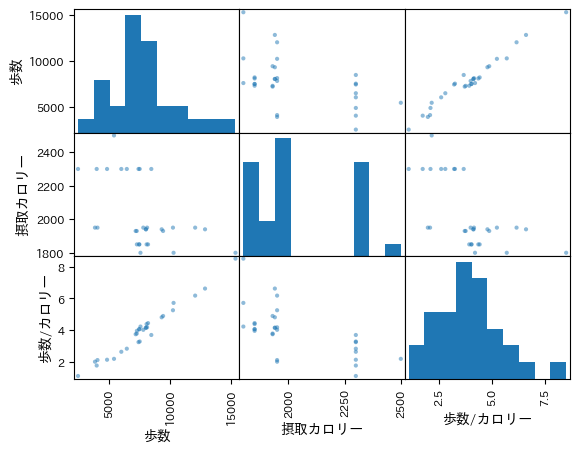

In [128]:
_ = scatter_matrix(df)

In [129]:
df[['歩数', '摂取カロリー']]

,歩数,摂取カロリー
date,,
2017-04-01,5439,2500.0
2017-04-02,2510,2300.0
2017-04-03,10238,1950.0
2017-04-04,8209,1850.0
2017-04-05,9434,1930.0
2017-04-06,7593,1800.0
2017-04-07,9320,1940.0
2017-04-08,4873,2300.0
2017-04-09,12045,1950.0


In [130]:
df[['歩数', '摂取カロリー']].values

array([[ 5439.,  2500.],
       [ 2510.,  2300.],
       [10238.,  1950.],
       [ 8209.,  1850.],
       [ 9434.,  1930.],
       [ 7593.,  1800.],
       [ 9320.,  1940.],
       [ 4873.,  2300.],
       [12045.,  1950.],
       [ 7493.,  1850.],
       [ 7289.,  1930.],
       [ 6481.,  2300.],
       [10287.,  1800.],
       [ 8043.,  1940.],
       [ 7435.,  2300.],
       [ 7529.,  2300.],
       [ 8031.,  1940.],
       [ 8475.,  2300.],
       [ 8132.,  1950.],
       [15328.,  1800.],
       [12849.,  1940.],
       [ 4029.,  2300.],
       [ 3890.,  1950.],
       [ 8093.,  1850.],
       [ 7823.,  1950.],
       [ 7492.,  1850.],
       [ 7203.,  1930.],
       [ 7302.,  1850.],
       [ 6033.,  2300.],
       [ 4093.,  1950.]])